In [4]:
import sys
sys.path.append("../utils")
import utils as ut
import preprocess as pc
import plot_config as pco
import hydro_storage as hs
import energy_analysis as ea
import pandas as pd
import xarray as xr
from tqdm import tqdm
import glob
from datetime import timedelta
from tqdm import tqdm

# Create double cooling dataset

In [2]:
# =================================================================================================================================================================================================
# === Preprocesses the climate2energy-converted data from CESM2 into nc files: for each technology separately, and together (as raw output, and combined with capacity scenarios, as net load). ===
# === Also saves capacity technology as a nc file =================================================================================================================================================
# =================================================================================================================================================================================================

# === Nomenclature ===
techs = {"PV":"",
         "cooling-demand":"",
         "heating-demand":{"fully_electrified":"_fully-electrified","current_electrified":""},
         "Wind-power":"",
         "hydro_inflow":"",
         "hydro_ror":"",
        }# all technologies considered
tech_names = ["PV","cooling-demand","heating-demand","Wind_onshore","Wind_offshore","hydro_inflow","hydro_ror"] #naming conventions for data set built here
generation = ["PV","Wind_onshore","Wind_offshore","hydro_ror"] # variables that generate energy
demand = ["heating-demand","cooling-demand","weather-insensitive_demand"] # variables that demand energy

out_path = '/net/xenon/climphys/lbloin/energy_boost/' #save location

In [3]:
boost = "" # "" if not boost, date of boost otherwise
boost_realization = "" 
boost_save = ""

for scenario in ["SSP370","historical"]:   
    # # === get Clim2Energy converted data sets for historical and SSP370 ===
    # abs_output = xr.open_dataset(f"{out_path}eng_vars_GWh_{scenario}{boost_save}.nc")["eng_vars"]

    # # === Calculate simple net load /without/ hydro inflow storage nor transmission effects === 
    # print("Calculate simple net load with no extra effects")
    # # #sum over technologies
    # abs_vars_tech_sum = -abs_output.sel(technology=generation).sum(dim="technology") + abs_output.sel(technology=demand).sum(dim="technology") + abs_output.sel(technology="cooling-demand") #add cooling one extra time to double effect
    # abs_vars_tech_sum.to_dataset(name="net_load").to_netcdf(f"{out_path}net_load_by_country_simple_{scenario}{boost_save}_double_cooling.nc")

    # # === Calculate simple net load /with/ hydro inflow storage effects === 
    # print("Calculate net load with hydro storage")
    # # calculate hydro_inflow (only keep countries that have hydro inflow)
    # hydro_inflow_full = abs_output.sel(technology="hydro_inflow").dropna(dim="country",how="all")
    # # open optimized storage from francesco's energy model
    # storage_ds = hs.open_storage(scenario,"")
    # storage_roll= storage_ds.rolling(time=24*21,center=True).mean().stack(dim=("member","time")) # rolling average to smooth the curve
    # storage_max = storage_ds.max(("member","time")) #max value, to cap the storage
    # if len(boost) == 0:
    #     starting_storage = storage_ds.groupby('time.dayofyear')[1].mean(("member","time")) # mean storage level on January 1st (used as starting point)
    # else:
    #     starting_storage = hs.get_boosted_start_storage(scenario,str(ut.str_to_cftime_noleap(boost)-timedelta(days=7))[0:10],storage_ds,boost_realization)
    # # calculate and save hydro storage effects
    # net_load_with_hydro = hs.storage_net_load_all_dims(abs_vars_tech_sum,techs,hydro_inflow_full,storage_roll,storage_max,starting_storage,boost)
    # net_load_with_hydro.to_netcdf(f"{out_path}net_load_by_country_hydro_storage_{scenario}{boost_save}_double_cooling.nc")
    # net_load_with_hydro.sum("country").to_netcdf(f"{out_path}net_load_hydro_storage_{scenario}{boost_save}_double_cooling.nc")
    net_load_with_hydro = xr.open_dataset(f"{out_path}net_load_by_country_hydro_storage_{scenario}{boost_save}_double_cooling.nc").dropna(dim="time")
    # === Calculate net load with transmission effects between countries === 
    print("Calculate transmission effects")
    net_load_transmission = []
    for heating_scenario in net_load_with_hydro.heating_scenario:
        ds_capac = []
        for capacity_scenario in net_load_with_hydro.capacity_scenario:
            ds_mem = []
            for member in net_load_with_hydro.member:
                # create transmission effect calculation framework
                analysis = ea.EnergyAnalysis(net_load_with_hydro.sel(member=member,capacity_scenario=capacity_scenario,heating_scenario=heating_scenario).net_load_adjusted.dropna(dim="time",how="all") )
                #calculate transmission effects
                ds_mem.append(ea.get_transmission_effect(analysis).to_xarray())
            ds_capac.append(xr.concat(ds_mem,dim=pd.Index(net_load_with_hydro.member,name="member")))
        #do it for all scenarios
        net_load_transmission.append(xr.concat(ds_capac,dim=pd.Index(net_load_with_hydro.capacity_scenario,name="capacity_scenario")))
    net_load_transmission = xr.concat(net_load_transmission,dim=pd.Index(net_load_with_hydro.heating_scenario,name="heating_scenario")).rename({"index":"time"})
    net_load_transmission["time"] = net_load_with_hydro.time # make sure the new data array has the same time dimension
    #save
    net_load_transmission.to_dataset(name="net_load").to_netcdf(f"{out_path}net_load_transmission_{scenario}{boost_save}_double_cooling.nc")

Calculate transmission effects


100%|██████████| 175200/175200 [00:36<00:00, 4779.00it/s]


Calculate transmission effects


100%|██████████| 175200/175200 [00:40<00:00, 4288.90it/s]


# Open files

In [2]:
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
import numpy as np
import string

# =================
# === Functions === 
# =================

def plot_p90(typ,ax,p90,scenario,i):
    """
    Plots all p90 events either as day of year or hour of day (specified through typ) for a given scenario and for a figure ax and color i
    """
    if typ == "doy":
        doy = p90.groupby("time.dayofyear").mean()
        to_plot = ut.get_smoothed_doy(doy,21) # smooth with a 21 day rolling mean
        ax.fill_between(to_plot.dayofyear,0,to_plot,alpha=0.3,color=pco.colors[1-i],label=ut.scen_config_dict[scenario])

    elif typ == "hod":
        to_plot = p90.groupby("time.hour").mean()
        ax.fill_between(to_plot.hour,0,to_plot,alpha=0.3,color=pco.colors[1-i],label=ut.scen_config_dict[scenario])

    print(to_plot.sum().values)
    ax.set_title(f"")
    if typ == "doy":
        ax.set_xticks([60,152,244,335],labels=["Mar","Jun","Sep","Dec"])
    elif typ == "hod": 
        ax.set_xlabel("Hour of day")
        ax.set_xticks([3,9,15,21])
    #plot configs
    ax.set_ylabel("")

# ==================
# === Open files ===
# ==================

path = "/net/xenon/climphys/lbloin/energy_boost/"
# get net load for different scenarios and assumptions
nl = {}
for scenario in  ut.CESM2_REALIZATION_DICT: 
    nl_scen = {
        "copperplate":xr.open_dataset(f"{path}net_load_hydro_storage_{scenario}_double_cooling.nc").net_load_adjusted,
        "copperplate_old":xr.open_dataset(f"{path}net_load_hydro_storage_{scenario}.nc").net_load_adjusted,
        "realistic_transmission":xr.open_dataset(f"{path}net_load_transmission_{scenario}_double_cooling.nc").net_load
    }
    nl[scenario] = nl_scen

#list of different scenarios and assumptions
transmission_types = ["copperplate","realistic_transmission"]
capacity_scenarios = nl[scenario]["copperplate"].capacity_scenario.values
heating_scenarios = nl[scenario]["copperplate"].heating_scenario.values
scenario_configs = [["current","current_electrified"],["future","fully_electrified"],["future_wind_x2","current_electrified"]]

# get 90th percentile for all climate model data combined, but separate for each scenario
qu_all = []
for typ in transmission_types:
    qu_capac = []
    for x,capacity_scenario in enumerate(capacity_scenarios):
        qu_heat = []
        for j,heating_scenario in enumerate(heating_scenarios):
            nl_for_qu = []
            for scenario in nl.keys():
                nl_for_qu.append(nl[scenario][typ].sel(capacity_scenario=capacity_scenario,heating_scenario=heating_scenario).dropna(dim='time').values)
            qu_heat.append(np.quantile(np.array(nl_for_qu),0.9))
        qu_capac.append(qu_heat)
    qu_all.append(qu_capac)
qu_all = xr.DataArray(
    qu_all,
    dims=["transmission_type","capacity_scenario","heating_scenario"],
    coords = {"transmission_type":transmission_types,"capacity_scenario":capacity_scenarios,"heating_scenario":heating_scenarios}
)

# plot distribution and frequency plots

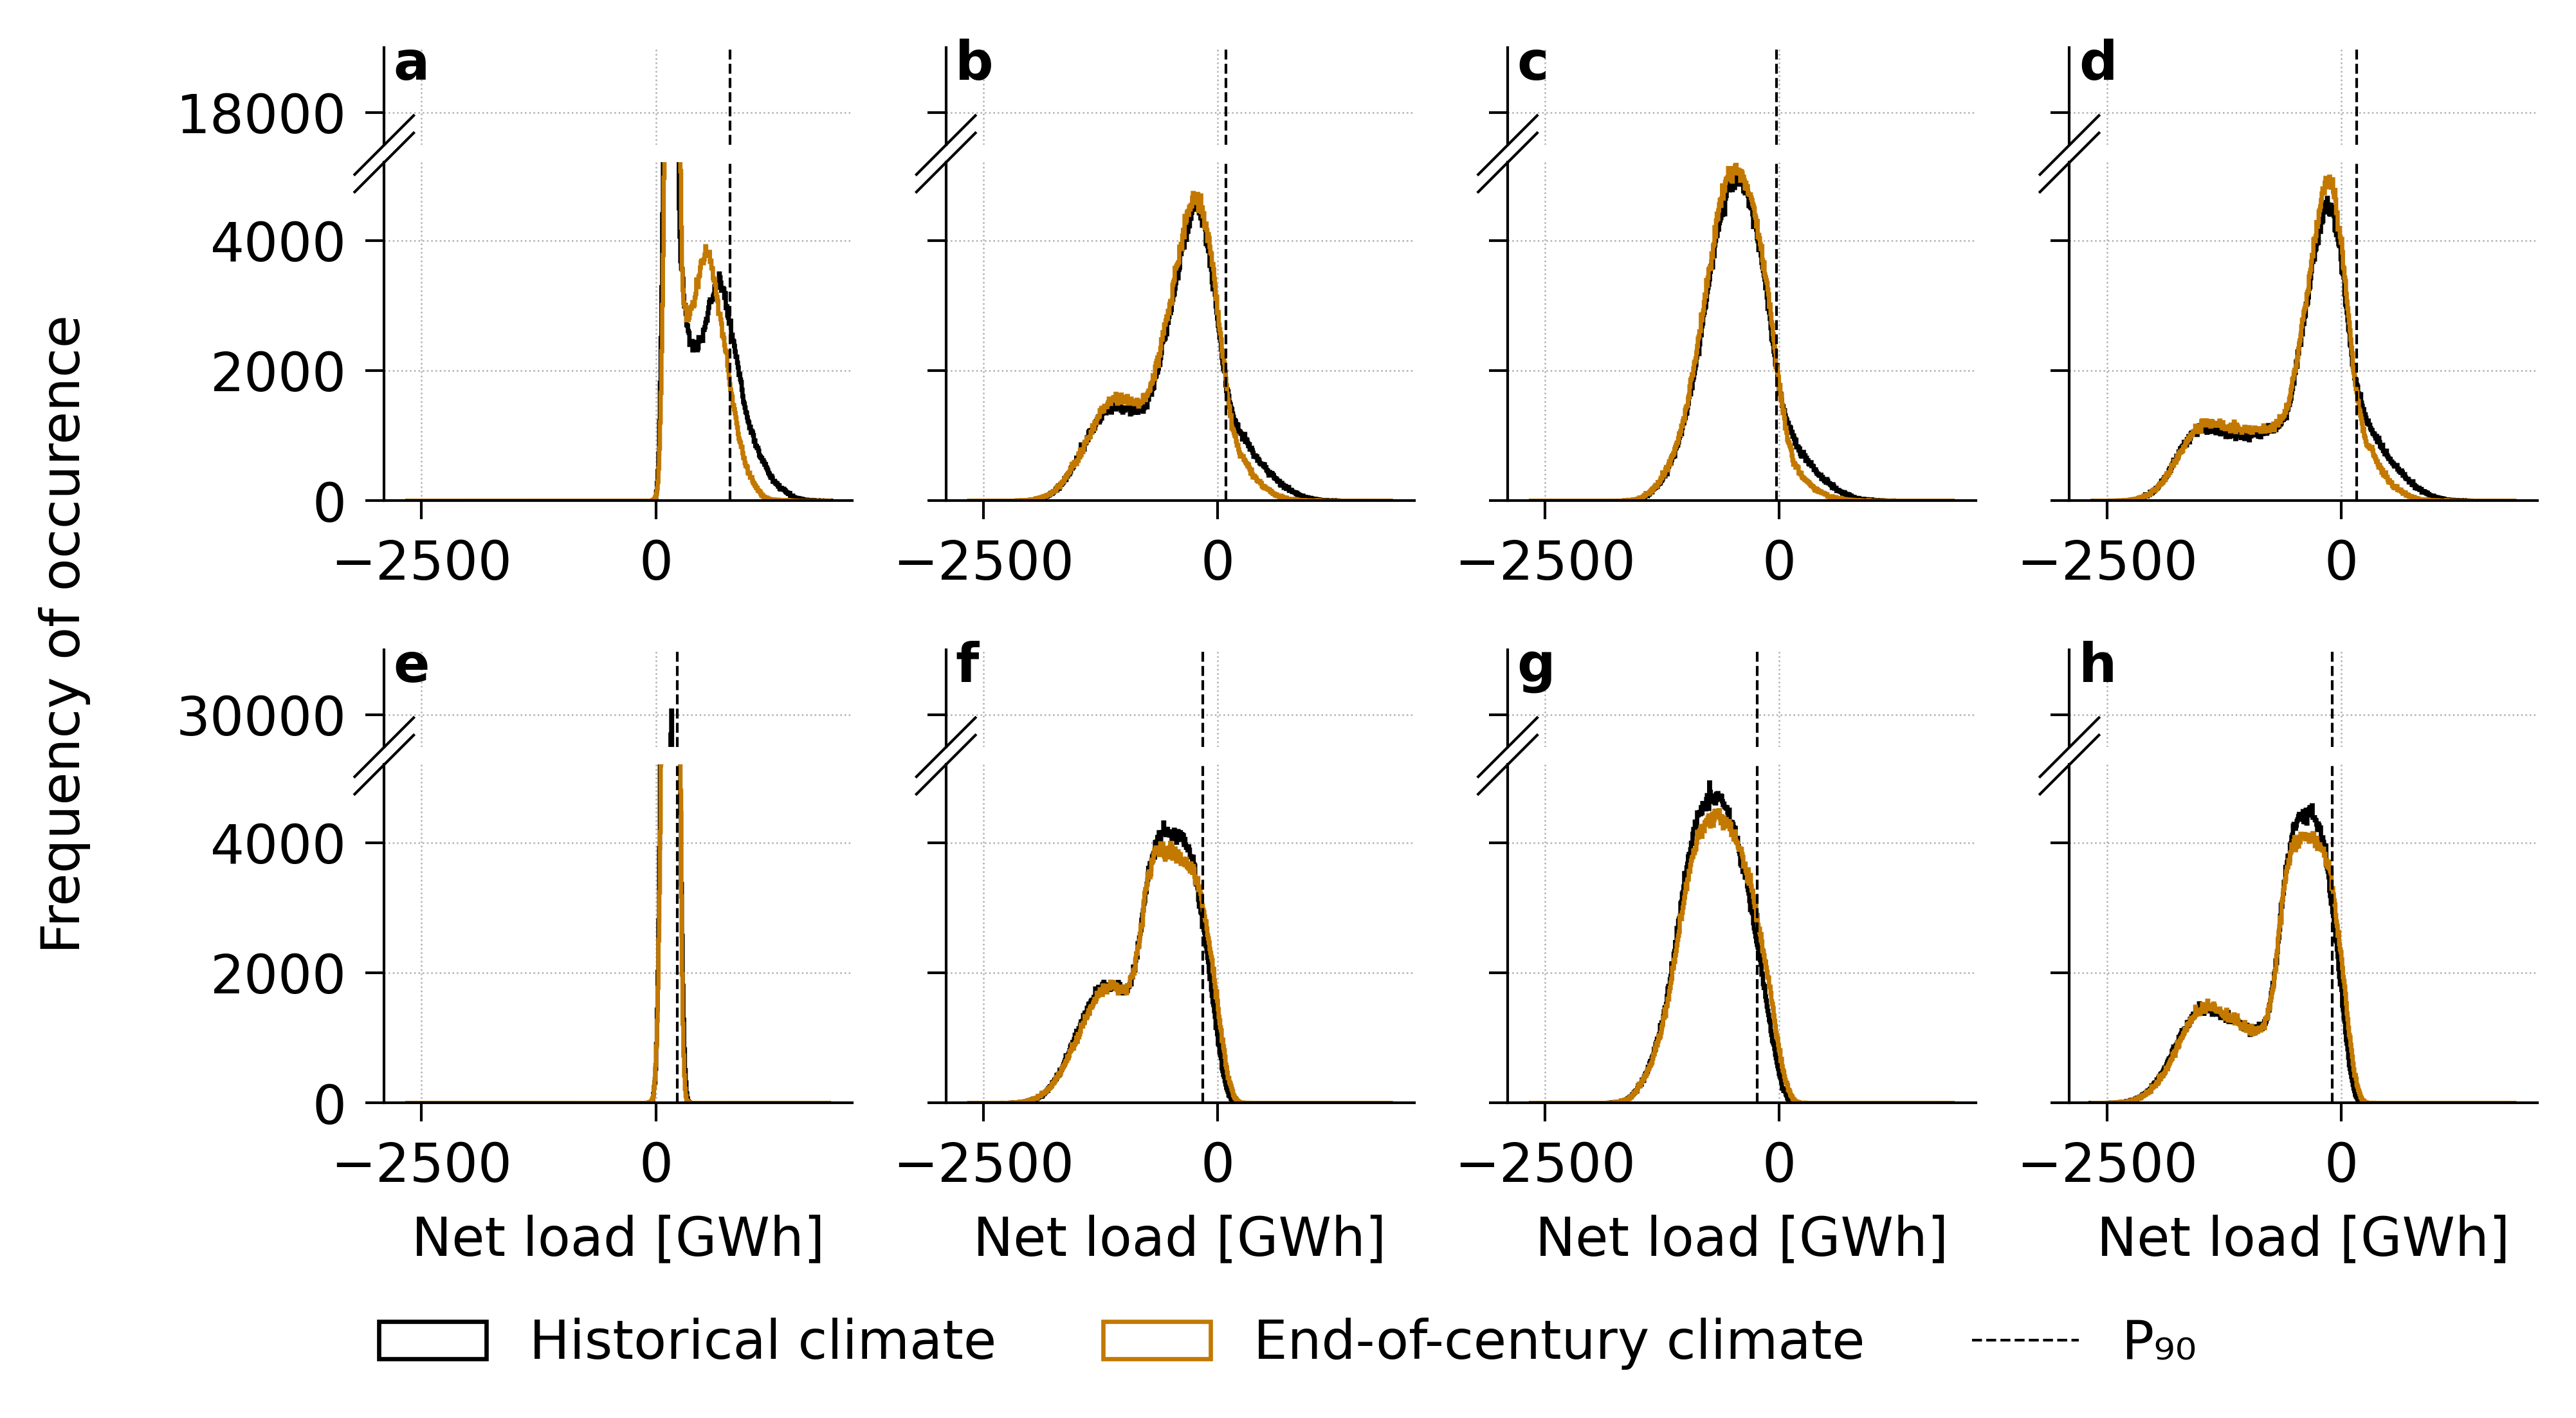

In [3]:
# =============
# === Fig 2 ===
# =============

#find common bins
nl_vals = []
for scenario in  ut.CESM2_REALIZATION_DICT:
    nl_vals.append(nl[scenario]["copperplate"].stack(dim=("time","member","heating_scenario","capacity_scenario")).values)
bins = np.histogram_bin_edges(nl_vals, bins='auto')

# figure
fig = plt.figure(figsize=(7.2, 4))
gs = GridSpec(4, 4, figure=fig,height_ratios=[1,0.1,1,0.18])
ylims =  [((0, 5200),(17500,19000)),((0, 5200),(29500,31000))]# 0.0013), (0.004, 0.0043)),((0, 0.0013), (0.007, 0.0073))]
for x, heating_scenario in enumerate(heating_scenarios):
    for j, capacity_scenario in enumerate(capacity_scenarios):
        spec = gs[x*2, j]
        # consistent broken y-limits
        bax = brokenaxes(ylims=ylims[x], hspace=0.08, subplot_spec=spec)

        for i, scenario in enumerate(ut.CESM2_REALIZATION_DICT):
            # Select relevant data
            data = nl[scenario]["copperplate"].sel(
                heating_scenario=heating_scenario,
                capacity_scenario=capacity_scenario
            )
            # Plot histogram on brokenaxes
            bax.hist(
                data.stack(dim=("time","member")).values,
                histtype="step",
                color=pco.colors[1 - i],
                label=f"{ut.scen_config_dict[scenario]}",
                bins=bins,
                linewidth=0.8,
            )

        # add p90 as vertical line
        bax.axvline(
            qu_all.sel(
                heating_scenario=heating_scenario,
                capacity_scenario=capacity_scenario,
                transmission_type="copperplate"
            ),
            linestyle = "dashed",
            color="k",
            linewidth=0.5,
            label = "P\u2089\u2080"
        )

        # Only show y-axis ticks on the leftmost column
        if j != 0:
            for axis in bax.axs:
                axis.tick_params(labelleft=False)
                
        if x ==1:
            bax.axs[1].set_xlabel("Net load [GWh]")
        for i,a in enumerate(bax.axs):
            pco.set_grid(a)
            if i ==0:
                a.text(0.02,0.67,string.ascii_lowercase[x*4+j%4],weight="bold",transform=a.transAxes)
fig.text(0.01,0.5,"Frequency of occurence",rotation='vertical',verticalalignment='center', horizontalalignment='center')
    
handles, labels = bax.axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',ncol=4, frameon=False)
plt.savefig(f"../../figs_CC_impacts/fig2_double_cooling.png",bbox_inches="tight", dpi = 600,transparent=True)

  0%|          | 0/3 [00:00<?, ?it/s]

33.3083333333333
2.19013698630137
39.691666666666706


 33%|███▎      | 1/3 [00:05<00:11,  5.78s/it]

2.6098630136986305
48.5402777777777
3.191689497716895
24.459722222222204


 67%|██████▋   | 2/3 [00:09<00:04,  4.36s/it]

1.608310502283105
29.5736111111111
1.9445662100456622
43.42638888888888


100%|██████████| 3/3 [00:12<00:00,  4.06s/it]

2.855433789954338


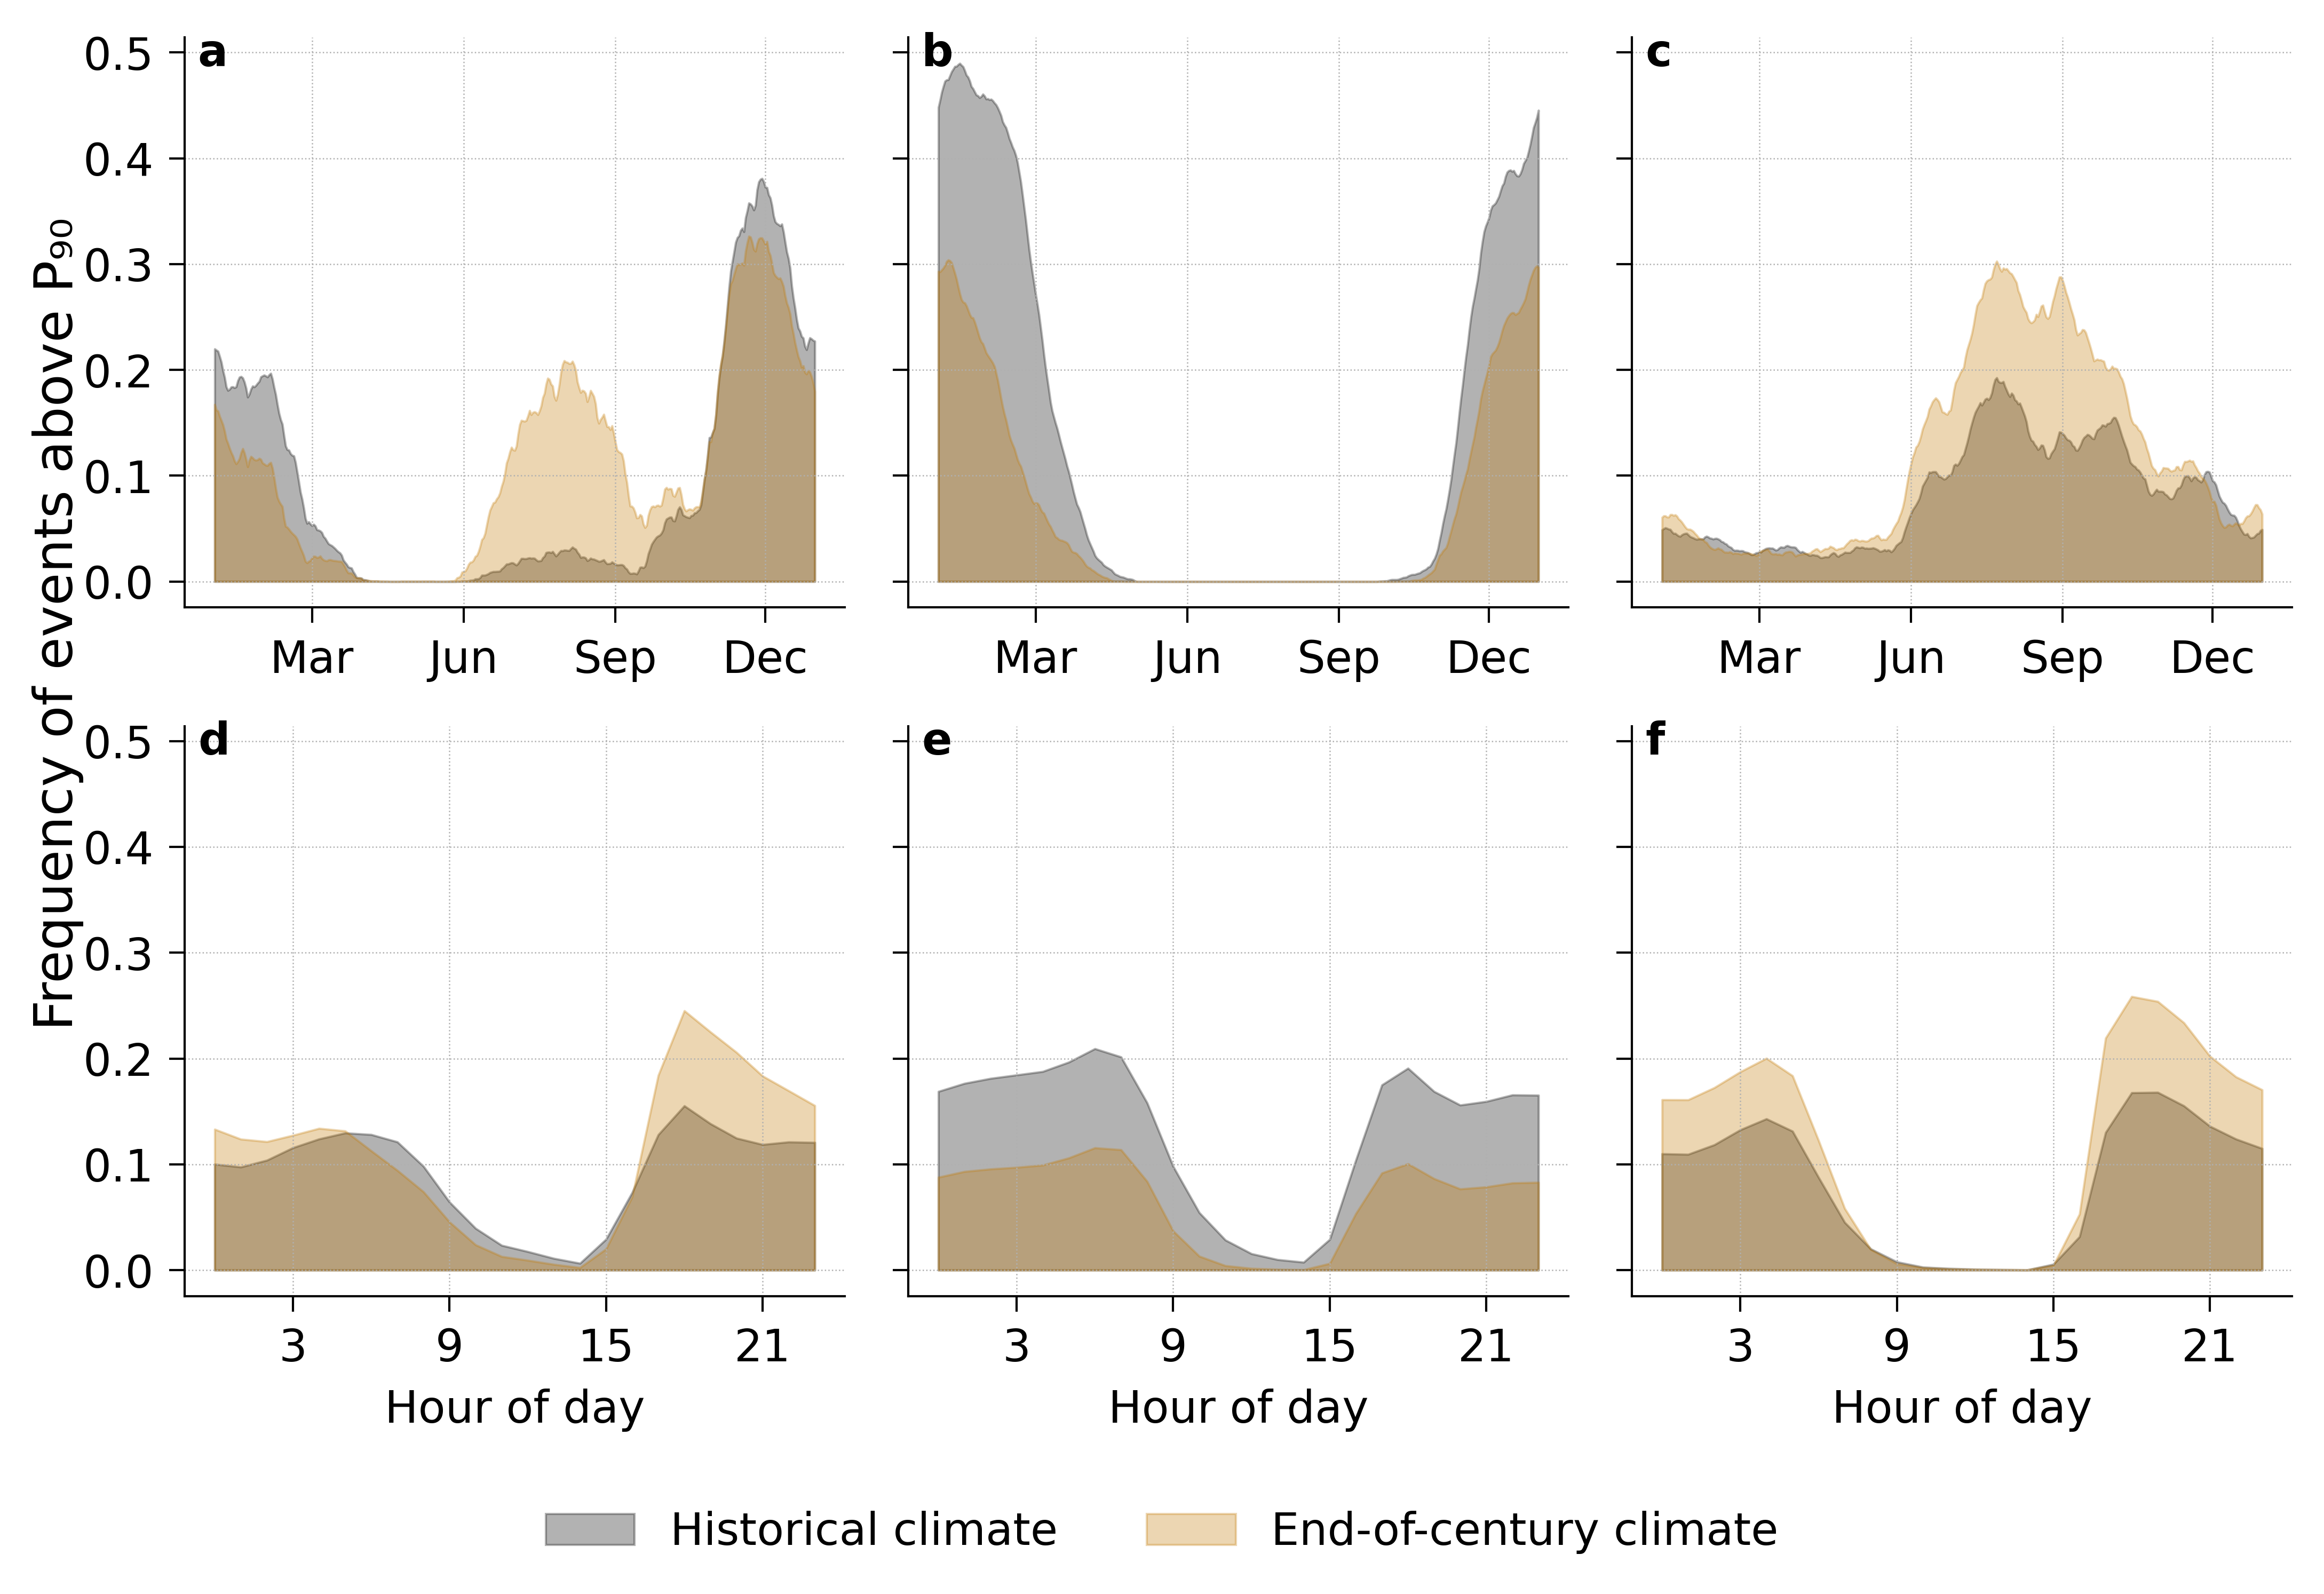

In [5]:
# =============
# === Fig 3 ===
# =============

# figure
f,ax=plt.subplots(2,3,figsize=(7.2,5),sharey=True)
for j,config in enumerate(tqdm(scenario_configs)):
    for i, scenario in enumerate(nl.keys()): #open hist and SSP370
        # get net load
        net_load = nl[scenario]["realistic_transmission"].sel(capacity_scenario=config[0],heating_scenario=config[1])
        net_load_stacked = net_load.stack(event=("member","time")).dropna(dim="event")
        # percentile to work with
        qu_nl = qu_all.sel(capacity_scenario=config[0],heating_scenario=config[1],transmission_type="realistic_transmission")
        # frequency of events above percentile
        ext = xr.where(net_load_stacked>qu_nl,1,0)
        # dayofyear
        plot_p90("doy",ax[0][j],ext,scenario,i)
        #hour of day
        plot_p90("hod",ax[1][j],ext,scenario,i)
    for x in [0,1]:
        pco.set_grid(ax[x][j])
        ax[x][j].text(0.02,0.95,string.ascii_lowercase[j+x*3],weight="bold",transform=ax[x][j].transAxes)
        ax[x][j].spines['right'].set_visible(False)
        ax[x][j].spines['top'].set_visible(False)
f.text(0.01,0.6,"Frequency of events above P\u2089\u2080",rotation='vertical',verticalalignment='center', horizontalalignment='center',fontsize=12)
handles, labels = ax[0][0].get_legend_handles_labels()
f.legend(handles, labels, loc='lower center',ncol=2, frameon=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(f"../../figs_CC_impacts/fig3_double_cooling.png",bbox_inches ="tight", dpi = 600)